In [1]:
import uproot
import numpy as np
import awkward as ak
import vector
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
vector.register_awkward()

In [2]:
f = uproot.open("/scratch/pvolkov/DM/samples/MultiLepton/matchedVars_short2/tT_LHE_Vars.root")
df = f['NNObjects'].arrays(library="pd")

In [4]:
def _stack2(a0, a1):
    return ak.Array(np.stack([np.asarray(a0), np.asarray(a1)], axis=1))

def _vec_from(prefix, data):
    return ak.zip(
        {
            "pt":  _stack2(data[f"{prefix}0_pt"],  data[f"{prefix}1_pt"]),
            "eta": _stack2(data[f"{prefix}0_eta"], data[f"{prefix}1_eta"]),
            "phi": _stack2(data[f"{prefix}0_phi"], data[f"{prefix}1_phi"]),
            "E":   _stack2(data[f"{prefix}0_e"],   data[f"{prefix}1_e"]),
        },
        with_name="Momentum4D",
    )

def _flav2(prefix, data):
    return ak.Array(np.stack([np.asarray(data[f"{prefix}0_flavor"]),
                              np.asarray(data[f"{prefix}1_flavor"])], axis=1))

def build_tops_vectorized(data):
    jets = _vec_from("gen_jet", data)
    jfl  = _flav2("gen_jet", data)

    leps = _vec_from("gen_lepton", data)
    lfl  = _flav2("gen_lepton", data)

    nus  = _vec_from("gen_nu", data)
    nfl  = _flav2("gen_nu", data)
    b = jets[ak.where(jfl > 0)]
    b_bar = jets[ak.where(jfl < 0)]

    lep_minus = leps[ak.where(lfl > 0)]
    lep_plus = leps[ak.where(lfl < 0)]

    nu  = nus[ak.where(nfl > 0)]
    nu_bar  = nus[ak.where(nfl < 0)]

    top  = b + lep_plus + nu
    tbar = b_bar + lep_minus + nu_bar

    return lep_minus, tbar, lep_plus, top

In [5]:
lep_minus, tbar, lep_plus, top = build_tops_vectorized(df)

In [6]:
vl_boosted1 = lep_minus.boostCM_of_p4(-tbar)
vl_boosted2 = lep_plus.boostCM_of_p4(-top)
hels = vl_boosted1.to_Vector3D().unit().dot(vl_boosted2.to_Vector3D().unit())

In [7]:
counts, edges = np.histogram(hels, density=True, bins=50)
bin_centers = (edges[:-1] + edges[1:]) / 2
coefficients = np.polyfit(bin_centers, counts, 1)

m, b = coefficients

print(f"Linear function: y = {m:.4f}x + {b:.4f}")
x = np.linspace(-1, 1, 100)
y_pred = np.polyval(coefficients, x)

Linear function: y = 0.0714x + 0.5000


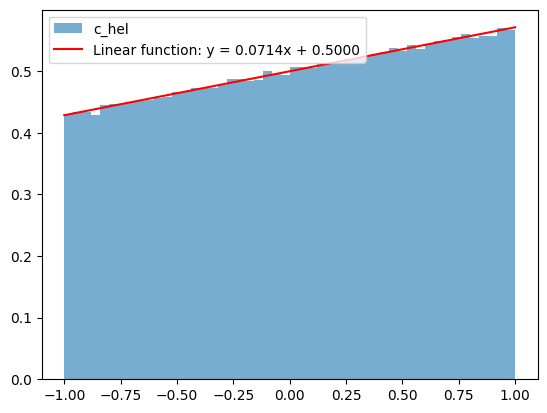

In [8]:
plt.hist(hels, density=True, label=f'c_hel', alpha=.6, bins=50)
plt.plot(x, y_pred, color='red', label = f'Linear function: y = {m:.4f}x + {b:.4f}')
plt.legend()
plt.savefig('4top_c_hel.png')
plt.show()

# NN

In [9]:
import torch
import uproot
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import lightning as L

In [10]:
# basic random seed
def seed_basic(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


# torch random seed
def seed_torch(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# basic + torch + lightning
def seed_everything(seed=42):
    seed_basic(seed)
    seed_torch(seed)
    L.seed_everything(seed)


seed_everything()

Seed set to 42


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Data preparation

In [12]:
train_raw_SM, test_raw_SM = train_test_split(df, test_size=0.2)
train_raw_SM, val_raw_SM = train_test_split(train_raw_SM, test_size=0.2)

train_raw = train_raw_SM
val_raw = val_raw_SM
test_raw = test_raw_SM

In [13]:
y_vars = ['gen_nu0_pt', 'gen_nu0_eta', 'gen_nu0_phi', 'gen_nu1_pt', 'gen_nu1_eta', 'gen_nu1_phi']
X_vars = ['gen_lepton0_pt', 'gen_lepton0_eta', 'gen_lepton0_phi', 'gen_lepton0_e', 'gen_lepton1_pt', 'gen_lepton1_eta', 'gen_lepton1_phi', 'gen_lepton1_e',
          'gen_jet0_pt', 'gen_jet0_eta', 'gen_jet0_phi', 'gen_jet0_e', 'gen_jet1_pt', 'gen_jet1_eta', 'gen_jet1_phi', 'gen_jet1_e']

In [14]:
scaler_y = StandardScaler()
scaler_y.fit(np.array(train_raw[y_vars]))
scaler_X = StandardScaler()
scaler_X.fit(np.array(train_raw[X_vars]))

X_train_df = pd.DataFrame(scaler_X.transform(np.array(train_raw[X_vars])), columns=X_vars)
X_val_df = pd.DataFrame(scaler_X.transform(np.array(val_raw[X_vars])), columns=X_vars)
X_test_df = pd.DataFrame(scaler_X.transform(np.array(test_raw[X_vars])), columns=X_vars)

y_train_df = pd.DataFrame(scaler_y.transform(np.array(train_raw[y_vars])), columns=y_vars)
y_val_df = pd.DataFrame(scaler_y.transform(np.array(val_raw[y_vars])), columns=y_vars)
y_test_df = pd.DataFrame(scaler_y.transform(np.array(test_raw[y_vars])), columns=y_vars)

In [15]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(
        self,
        input_values,
        labels,
        transforms=None,
    ):
        self.input_values = torch.from_numpy(input_values).type(torch.FloatTensor)
        self.labels = torch.from_numpy(labels).type(torch.FloatTensor)
        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if self.transforms:
            input_value = self.transforms(self.input_values[idx])
        else:
            input_value = self.input_values[idx]
        label = self.labels[idx]
        return input_value, label

In [16]:
train_set = CustomDataset(X_train_df.values, y_train_df.values)
val_set = CustomDataset(X_val_df.values, y_val_df.values)
test_set = CustomDataset(X_test_df.values, y_test_df.values)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=1024, shuffle=True, num_workers = 4
)
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1024, shuffle=False, num_workers = 4
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=1024, shuffle=False, num_workers = 4
)

In [17]:
import sys
sys.path.append('../src/')
import torch.nn as nn
import torch.nn.functional as F
import sc_models
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError

In [18]:
class LModel(L.LightningModule):

    def __init__(
            self, model, lr=1e-3,
        ):
        super().__init__()
        self.model = model
        self.criterion = nn.L1Loss()
        self.train_acc = MeanAbsoluteError()
        self.valid_acc = MeanAbsoluteError()
        self.lr = lr

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr = self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor = 0.1, min_lr = 1e-4)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "monitor": "loss/val",
            },
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self.model.forward(x)
        loss = self.criterion(out, y)
        self.train_acc.update((out.detach()), y.detach())
        self.log("loss/train", loss.detach().item(), prog_bar=True)
        return loss
        
    def on_train_epoch_end(self):
        self.log("MAE/train", self.train_acc.compute(), prog_bar=True)
        self.train_acc.reset()
        
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self.model.forward(x)
        loss = self.criterion(out, y)
        self.valid_acc.update((out.detach()), y.detach())
        self.log("loss/val", loss.detach().item())
        
    def on_validation_epoch_end(self):
        self.log("MAE/val", self.valid_acc.compute(), prog_bar=True)
        self.valid_acc.reset()


In [19]:
class LModel_NF(L.LightningModule):
    def __init__(
            self, model, lr=1e-3,
        ):
        super().__init__()
        self.model = model
        self.criterion = nn.L1Loss()
        self.train_acc = MeanAbsoluteError()
        self.valid_acc = MeanAbsoluteError()
        self.test_acc = MeanAbsoluteError()
        self.lr = lr

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr = self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor = 0.1, min_lr = 1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "monitor": "loss/val", 
            },
        }
    def training_step(self, batch, batch_idx):
        x, y = batch
        out = -self.model.log_prob(inputs=y, context=x)
        loss = -self.model.log_prob(inputs=y, context=x).mean()
        self.log("loss/train", loss.detach().item(), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = -self.model.log_prob(inputs=y, context=x)
        loss = -self.model.log_prob(inputs=y, context=x).mean()
        self.log("loss/val", loss.detach().item())

In [20]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import warnings
warnings.filterwarnings("ignore")

def create_trainer(name, max_epochs = 10):
    checkpoint_callback = ModelCheckpoint(
    dirpath='../checkpoints/2top/parton',
    save_last=False,
    every_n_epochs=1,
    save_top_k=1,
    monitor="loss/val",
    filename=name,
    mode="min",
    )

    torch.set_float32_matmul_precision('medium')
    trainer = L.Trainer(
        max_epochs=max_epochs,
        callbacks=[checkpoint_callback, EarlyStopping(monitor="loss/val", mode="min", patience = 5)],
        num_sanity_val_steps=1,
        log_every_n_steps=10,
        logger=L.pytorch.loggers.CSVLogger(save_dir=f"../logs/2top/parton/", name = name),
    )
    return trainer

In [21]:
mlp_model = sc_models.MLP_net(len(X_vars), len(y_vars), 500, 3, 0.15)
basic_flow = sc_models.Basic_flow(cond_size = len(X_vars), target_size = len(y_vars))
nu_flow = sc_models.Nu_flow(encoder = sc_models.DeepSet(len(X_vars), 31), target_size = len(y_vars), 
                            masking_order = [1, 1, -1, 1, 1, -1],  # masking is done for (x,y) <-> z for neutrino and mediator
                            num_layers = 4, context_size = 31, spline_conf = (100, 2, 0.1))

## Training Block

In [239]:
pl_model_mlp = LModel(mlp_model)
trainer = create_trainer("mlp", max_epochs = 100)
trainer.fit(
    model=pl_model_mlp,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params
------------------------------------------------
0 | model     | MLP_net           | 512 K 
1 | criterion | L1Loss            | 0     
2 | train_acc | MeanAbsoluteError | 0     
3 | valid_acc | MeanAbsoluteError | 0     
------------------------------------------------
512 K     Trainable params
0         Non-trainable params
512 K     Total params
2.050     Total estimated model params size (MB)


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

In [307]:
pl_model_basic_flow = LModel_NF(basic_flow)
trainer = create_trainer("basic_flow", max_epochs = 10)
trainer.fit(
    model=pl_model_basic_flow,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: ../logs/2top/parton/basic_flow
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params
------------------------------------------------
0 | model     | Basic_flow        | 375 K 
1 | criterion | L1Loss            | 0     
2 | train_acc | MeanAbsoluteError | 0     
3 | valid_acc | MeanAbsoluteError | 0     
4 | test_acc  | MeanAbsoluteError | 0     
------------------------------------------------
375 K     Trainable params
0         Non-trainable params
375 K     Total params
1.500     Total estimated model params size (MB)


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


In [308]:
pl_model_nu_flow = LModel_NF(nu_flow)
trainer = create_trainer("nu_flow", max_epochs = 15)
trainer.fit(
    model=pl_model_nu_flow,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: ../logs/2top/parton/nu_flow
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params
------------------------------------------------
0 | model     | Nu_flow           | 179 K 
1 | criterion | L1Loss            | 0     
2 | train_acc | MeanAbsoluteError | 0     
3 | valid_acc | MeanAbsoluteError | 0     
4 | test_acc  | MeanAbsoluteError | 0     
------------------------------------------------
179 K     Trainable params
0         Non-trainable params
179 K     Total params
0.719     Total estimated model params size (MB)


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=15` reached.


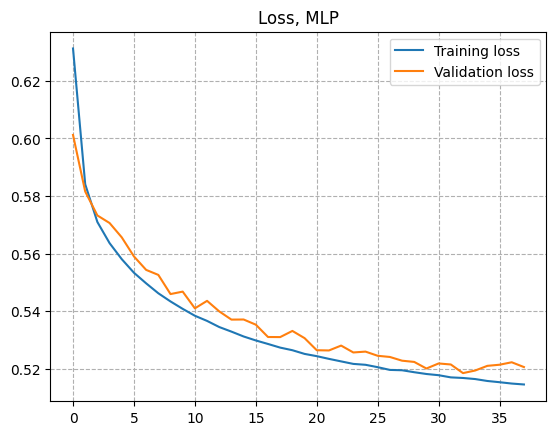

In [240]:
metrics = pd.read_csv("../logs/2top/parton/mlp/version_2/metrics.csv")
metircs_epoch = metrics.groupby("epoch").mean()
fig = plt.Figure(figsize = (8,6))
plt.plot(metircs_epoch["MAE/train"], label = "Training loss")
plt.plot(metircs_epoch["MAE/val"], label = "Validation loss")
plt.grid(linestyle = "--")
plt.title("Loss, MLP")
plt.legend()
plt.savefig("../plots/parton/MLP_loss.pdf")
plt.show()

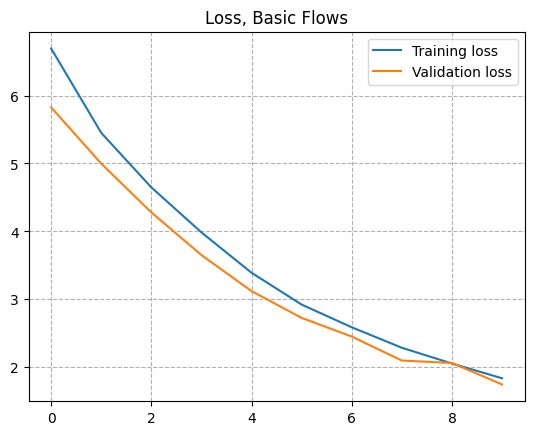

In [309]:
metrics = pd.read_csv("../logs/2top/parton/basic_flow/version_0/metrics.csv")
metircs_epoch = metrics.groupby("epoch").mean()
fig = plt.Figure(figsize = (8,6))
plt.plot(metircs_epoch["loss/train"], label = "Training loss")
plt.plot(metircs_epoch["loss/val"], label = "Validation loss")
plt.grid(linestyle = "--")
plt.title("Loss, Basic Flows")
plt.legend()
plt.savefig("../plots/parton/Basic_flows_loss.pdf")
plt.show()

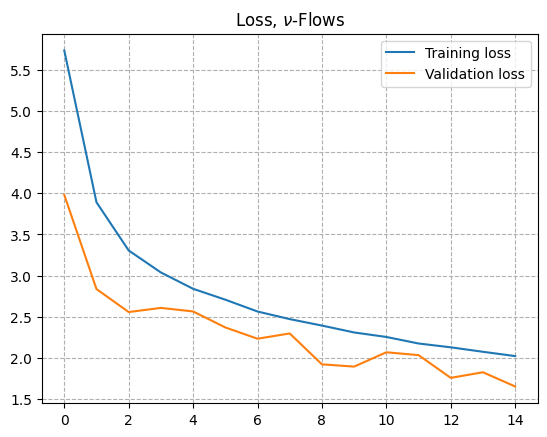

In [310]:
metrics = pd.read_csv("../logs/2top/parton/nu_flow/version_0/metrics.csv")
metircs_epoch = metrics.groupby("epoch").mean()
fig = plt.Figure(figsize = (8,6))
plt.plot(metircs_epoch["loss/train"], label = "Training loss")
plt.plot(metircs_epoch["loss/val"], label = "Validation loss")
plt.grid(linestyle = "--")
plt.title(r"Loss, $\nu$-Flows")
plt.legend()
plt.savefig("../plots/parton/Nu_flows_loss.pdf")
plt.show()

## Inference

In [23]:
checkpoint = torch.load('../checkpoints/2top/parton/mlp-v3.ckpt')
state_dict = checkpoint["state_dict"]
model_dict = {key.removeprefix("model."):val for key, val in state_dict.items()}
mlp_model.load_state_dict(model_dict)

checkpoint = torch.load('../checkpoints/2top/parton/basic_flow.ckpt')
state_dict = checkpoint["state_dict"]
model_dict = {key.removeprefix("model."):val for key, val in state_dict.items()}
basic_flow.load_state_dict(model_dict)

checkpoint = torch.load('../checkpoints/2top/parton/nu_flow.ckpt')
state_dict = checkpoint["state_dict"]
model_dict = {key.removeprefix("model."):val for key, val in state_dict.items()}
nu_flow.load_state_dict(model_dict)

<All keys matched successfully>

In [24]:
X_test = pd.DataFrame(scaler_X.transform(np.array(test_raw[X_vars])), columns=X_vars)
y_test = pd.DataFrame(scaler_y.transform(np.array(test_raw[y_vars])), columns=y_vars)
y_test_unscaled = scaler_y.inverse_transform(y_test)

In [25]:
from pathlib import Path
def plot_targets(y_vars, pred, y_test_unscaled, bins = 100, alpha = 0.5, 
                bin_ranges = [(0, 500), (-5, 5), (-5, 5), (0, 500), (-5, 5), (-5, 5)],
                name = 'MLP'):
    fig, ax = plt.subplots(2, 3, figsize = (16, 9))
    ax = ax.ravel()
    for i in range(len(y_vars)):
        ax[i].hist(pred[:, i], bins=bins, alpha=alpha, range=bin_ranges[i], label='reconstructed')
        ax[i].hist(y_test_unscaled[:, i], bins=bins, alpha=alpha, range=bin_ranges[i], label='true')
        ax[i].set_xlabel(y_vars[i], fontsize = 14)
    fig.suptitle(f"{name} reconstruction", fontsize = 20)
    fig.tight_layout()
    ax[0].legend()
    name = name.replace('$', '').replace('\\', '')
    Path("../plots/parton/2top").mkdir(parents=True, exist_ok=True)
    plt.savefig(f"../plots/parton/2top/{name}_momentum.pdf")
    plt.show()

In [26]:
from torchmetrics.regression import MeanAbsoluteError
with torch.no_grad():
    pred_mlp = mlp_model.to(device).forward(torch.tensor(X_test.values, dtype = torch.float32).to(device)).cpu()
mean_absolute_error = MeanAbsoluteError()
print(f'MAE: {mean_absolute_error(torch.tensor(pred_mlp), torch.tensor(y_test.values)):.4f}')
pred_mlp = scaler_y.inverse_transform(pred_mlp)

MAE: 0.5170


In [27]:
y_vars_tex = [r"$P^{\nu1}_t$", r"${\eta}^{\nu1}$", r"${\phi}^{\nu1}$", r"$P^{\nu2}_t$", r"${\eta}^{\nu2}$", r"${\phi}^{\nu2}$"]

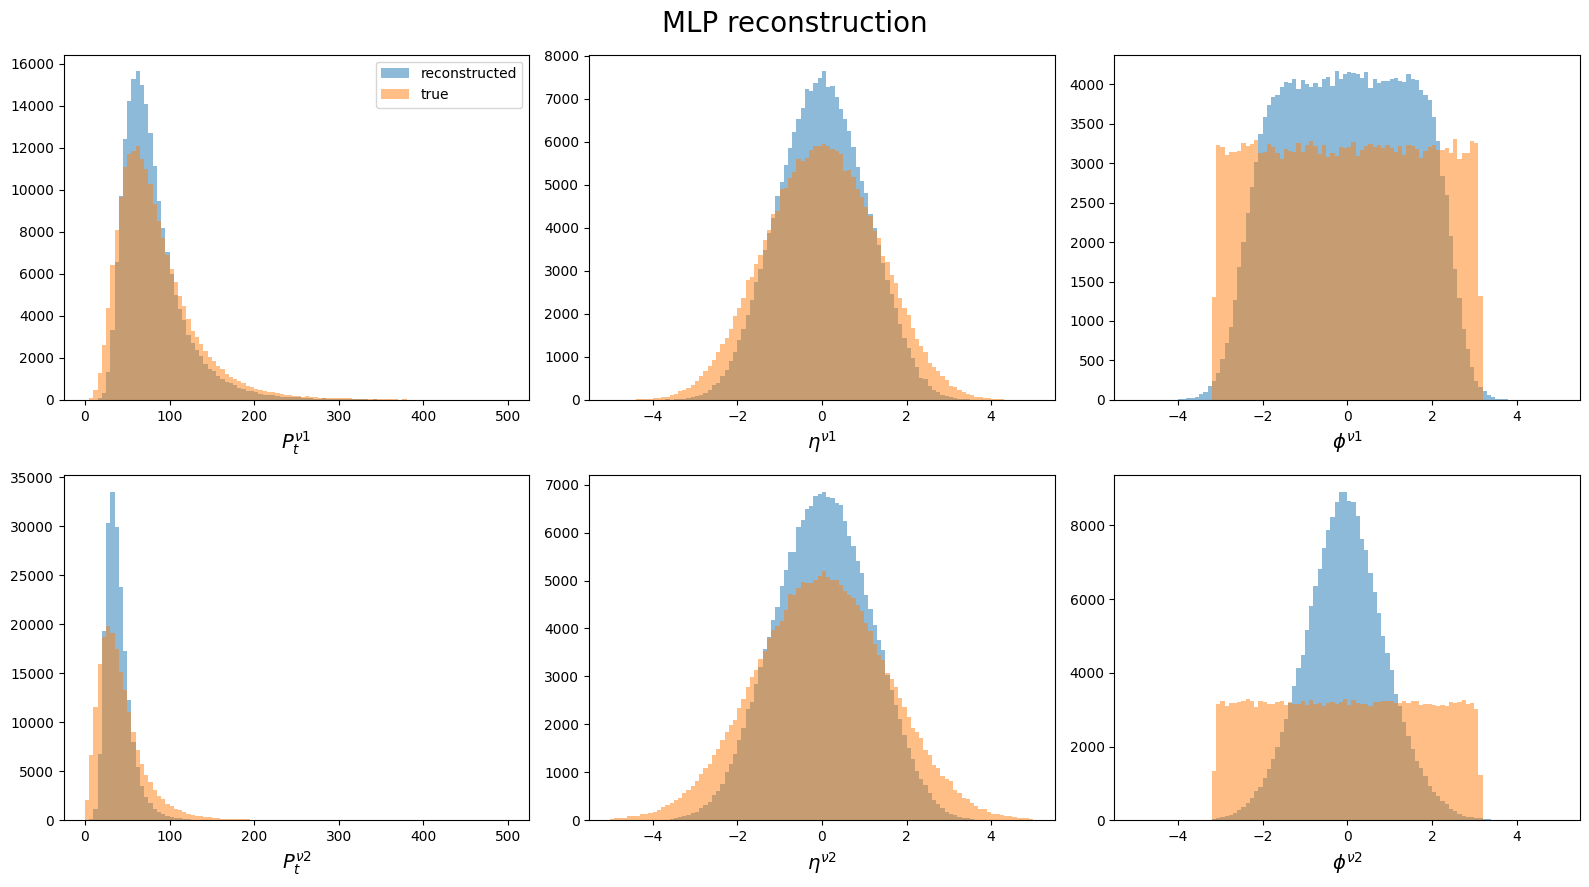

In [28]:
plot_targets(y_vars_tex, pred_mlp, y_test_unscaled, name = 'MLP')

In [29]:
with torch.no_grad():
    pred_flows, _= torch.median(basic_flow.to(device).sample(num_samples = 10, context=torch.tensor(X_test.values, dtype = torch.float32).to(device)), 1)
    pred_flows = pred_flows.cpu()
mean_absolute_error = MeanAbsoluteError()
pred_flows = torch.clamp(pred_flows, -10, 10) #Basic Flows can predict huge values, so clamp it to some reasonable range
pred_flows = scaler_y.inverse_transform(pred_flows)

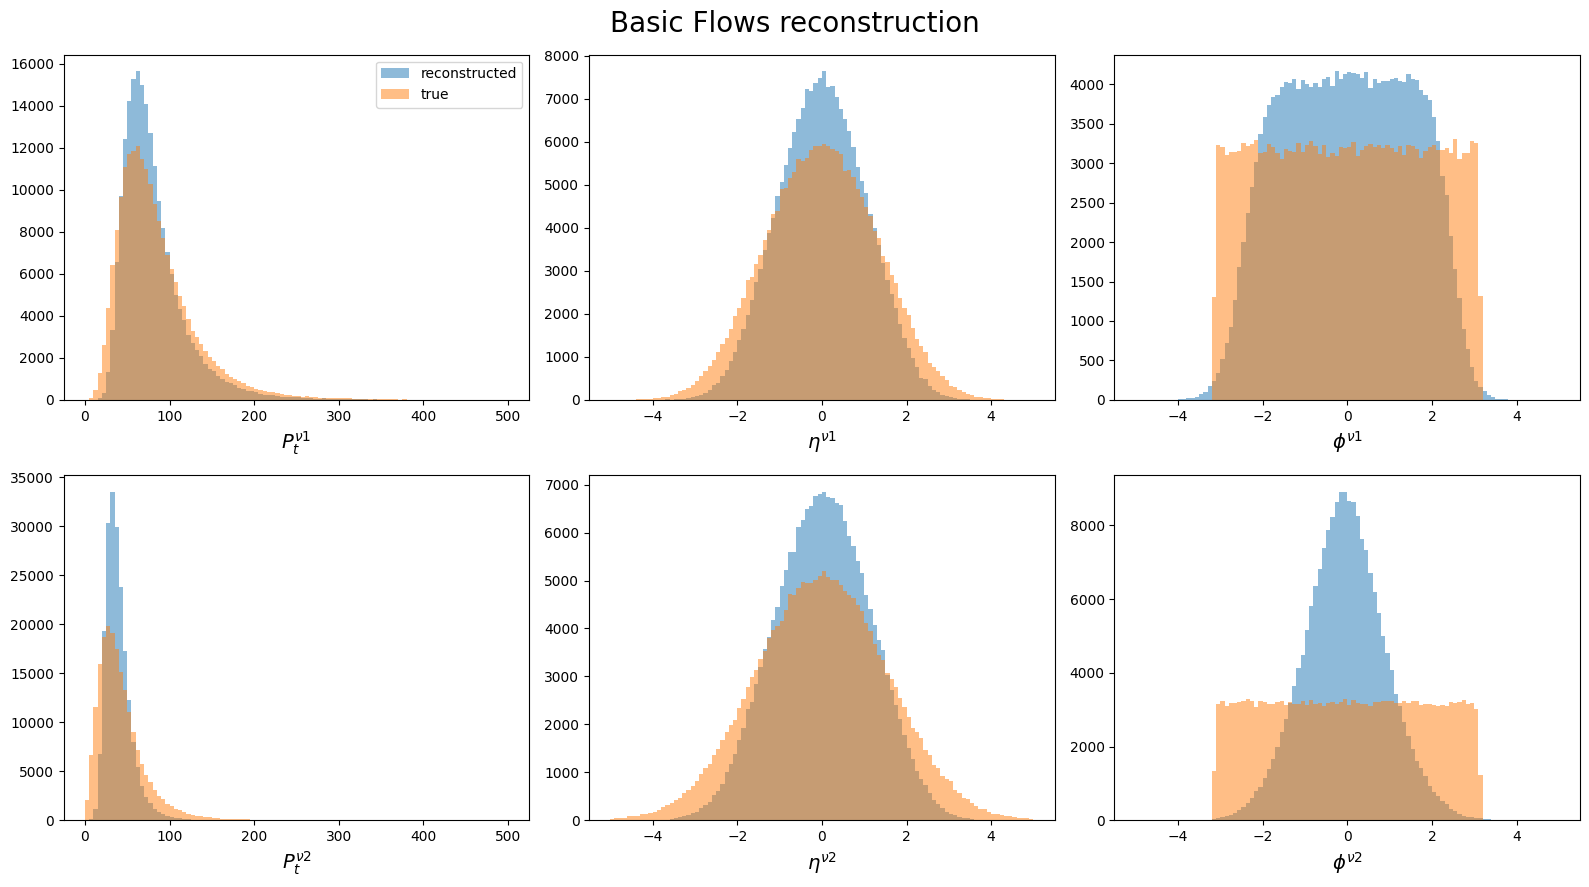

In [30]:
plot_targets(y_vars_tex, pred_mlp, y_test_unscaled, name = 'Basic Flows')

In [31]:
with torch.no_grad():
    pred_nuflows, _= torch.median(nu_flow.to(device).sample(num_samples = 5, context=torch.tensor(X_test.values, dtype = torch.float32).to(device)), 1)
    pred_nuflows = pred_nuflows.cpu()
mean_absolute_error = MeanAbsoluteError()
pred_nuflows = scaler_y.inverse_transform(pred_nuflows)

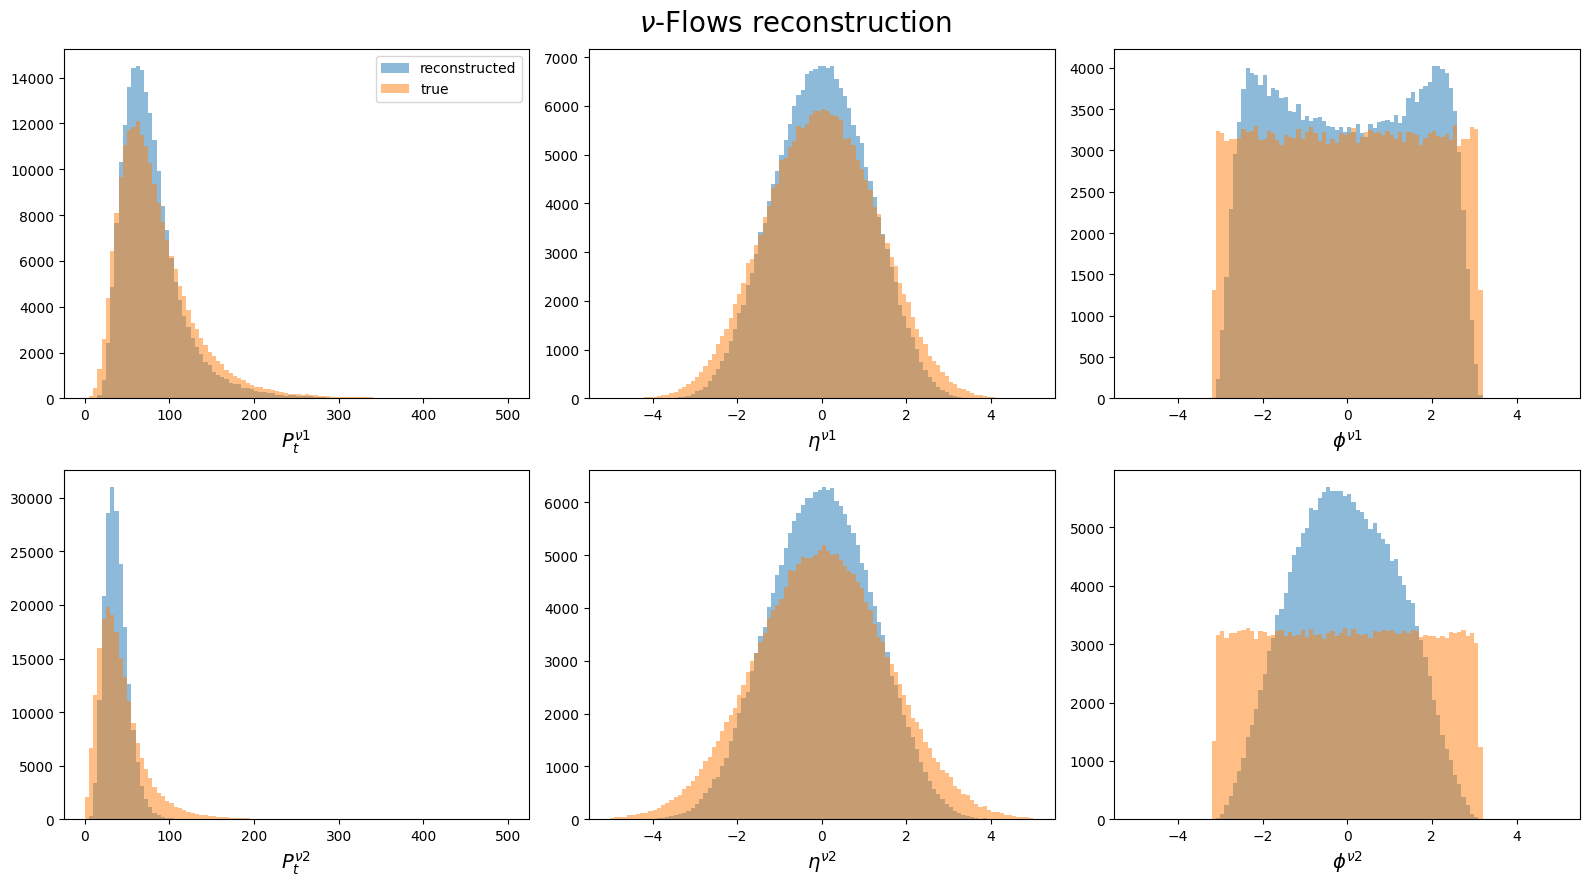

In [32]:
plot_targets(y_vars_tex, pred_nuflows, y_test_unscaled, name = r'$\nu$-Flows')

In [33]:
def build_tops_vectorized_pred(data):
    jets = _vec_from("gen_jet", data)
    jfl = _flav2("gen_jet", data)

    leps = _vec_from("gen_lepton", data)
    lfl = _flav2("gen_lepton", data)

    nus = ak.zip(
        {
            "pt":  _stack2(data[f"pred_nu0_pt"],  data[f"pred_nu1_pt"]),
            "eta": _stack2(data[f"pred_nu0_eta"], data[f"pred_nu1_eta"]),
            "phi": _stack2(data[f"pred_nu0_phi"], data[f"pred_nu1_phi"]),
            "M":   _stack2(data[f"gen_nu0_m"],   data[f"gen_nu1_m"]),
        },
        with_name="Momentum4D",
    )
    nfl = _flav2("gen_nu", data)
    b = jets[ak.where(jfl > 0)]
    b_bar = jets[ak.where(jfl < 0)]

    lep_minus = leps[ak.where(lfl > 0)]
    lep_plus = leps[ak.where(lfl < 0)]

    nu = nus[ak.where(nfl > 0)]
    nu_bar = nus[ak.where(nfl < 0)]

    top = b + lep_plus + nu
    tbar = b_bar + lep_minus + nu_bar

    return lep_minus, tbar, lep_plus, top

In [34]:
import re
pred_vars = [re.sub('gen', 'pred', var) for var in y_vars]

In [36]:
from scipy.stats import chisquare
def plot_cosine(pred, test_data, name, bins = 100, alpha = 0.5):
    pred_df = test_data.join(pd.DataFrame(pred, index=test_raw.index, columns=pred_vars))

    lep_minus, tbar, lep_plus, top = build_tops_vectorized(pred_df)
    vl_boosted1 = lep_minus.boostCM_of_p4(-tbar)
    vl_boosted2 = lep_plus.boostCM_of_p4(-top)
    hels = vl_boosted1.to_Vector3D().unit().dot(vl_boosted2.to_Vector3D().unit())
    
    lep_minus, tbar, lep_plus, top = build_tops_vectorized_pred(pred_df)
    vl_boosted1 = lep_minus.boostCM_of_p4(-tbar)
    vl_boosted2 = lep_plus.boostCM_of_p4(-top)
    hels_pred = vl_boosted1.to_Vector3D().unit().dot(vl_boosted2.to_Vector3D().unit())
    pred_hist = np.histogram(hels_pred, bins = bins)[0]
    true_hist = np.histogram(hels, bins = bins)[0]
    chi2 = chisquare(pred_hist, true_hist)[0]
    hist_mae = mean_absolute_error(torch.tensor(pred_hist), torch.tensor(true_hist))
    print(f'Chi-squared statistics: {chi2:.1f}')
    print(f'Histogram MAE: {hist_mae:.1f}')
    fig, ax = plt.subplots(1, figsize = (8, 6))
    plt.hist(hels_pred, density=True, bins=bins, alpha=alpha, label='reconstructed (neutrinr TRF)')
    plt.hist(hels, density=True, bins=bins, alpha=1, label='true (neutrino TRF)', histtype='step', linewidth = 2)
    plt.text(0.6, 0.9, f"Hist MAE: {hist_mae:.1f} \n $\chi^2$ score: {chi2:.1f}", fontsize = 12, transform=ax.transAxes, 
             horizontalalignment='left', verticalalignment='center',
             bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))
    plt.title(r'$cos(\mu, d)_{TRF}$ reconstruction, DM, ' + name)
    plt.legend()
    name = name.replace('$', '').replace('\\', '')
    plt.savefig(f"../plots/parton/2top/C_hel_SM_{name}.png")
    plt.show()

In [39]:
test_data = test_raw[X_vars + y_vars + ['gen_nu0_flavor', 'gen_nu1_flavor', 'gen_nu0_e', 'gen_nu1_e', 'gen_lepton0_flavor', 'gen_lepton1_flavor', 'gen_jet0_flavor', 'gen_jet1_flavor']]
test_data['gen_nu0_m'] = 0
test_data['gen_nu1_m'] = 0

Chi-squared statistics: 133.2
Histogram MAE: 85.7


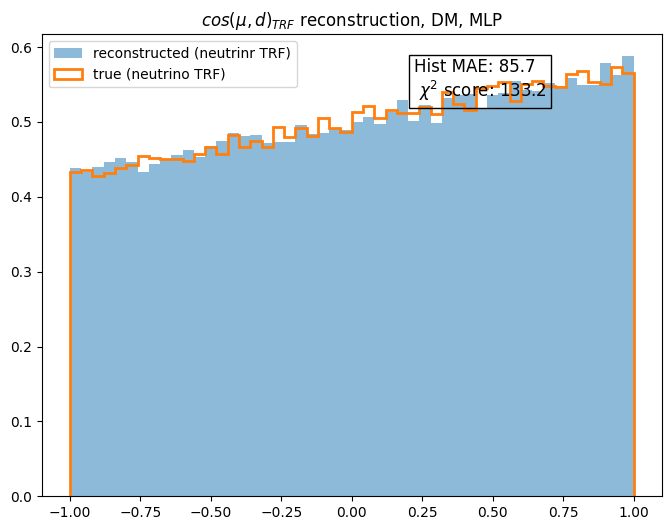

In [40]:
plot_cosine(pred_mlp, test_data, 'MLP', bins=50)

Chi-squared statistics: 121.1
Histogram MAE: 81.5


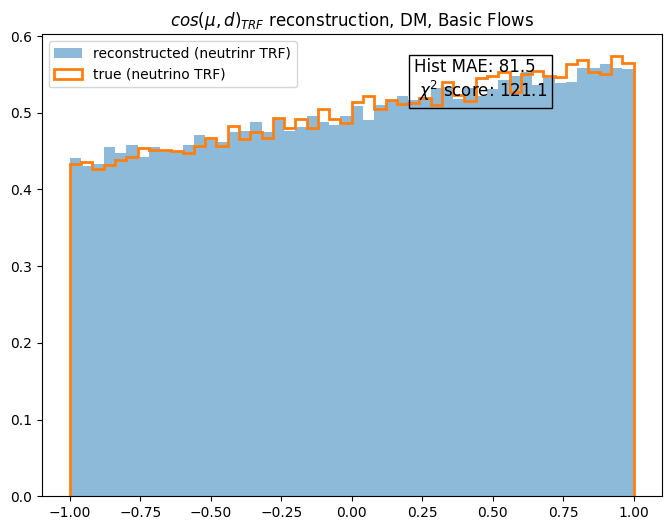

In [41]:
plot_cosine(pred_flows, test_data, 'Basic Flows', bins=50)

Chi-squared statistics: 116.3
Histogram MAE: 77.5


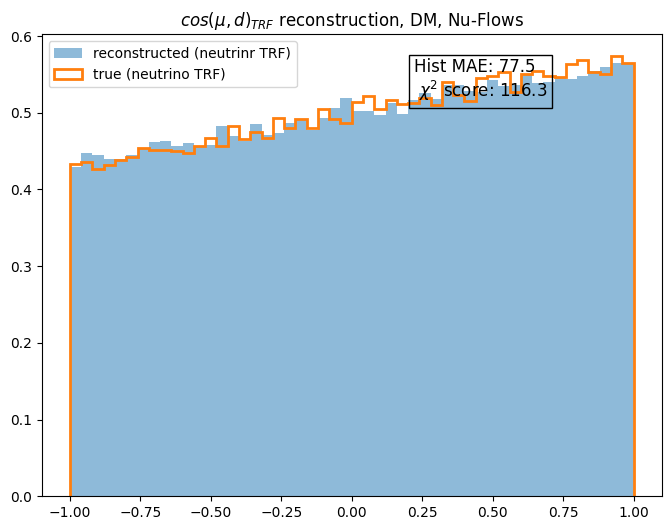

In [42]:
plot_cosine(pred_nuflows, test_data, 'Nu-Flows', bins=50)